In [2]:
import pandas as pd
import numpy as np

df_fd = pd.read_csv("df_final_demo.txt")
df_fec = pd.read_csv("df_final_experiment_clients.txt")
df_fwd1 = pd.read_csv("df_final_web_data_pt_1.txt")
df_fwd2 = pd.read_csv("df_final_web_data_pt_2.txt")

In [3]:
df_fd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70609 entries, 0 to 70608
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   client_id         70609 non-null  int64  
 1   clnt_tenure_yr    70595 non-null  float64
 2   clnt_tenure_mnth  70595 non-null  float64
 3   clnt_age          70594 non-null  float64
 4   gendr             70595 non-null  object 
 5   num_accts         70595 non-null  float64
 6   bal               70595 non-null  float64
 7   calls_6_mnth      70595 non-null  float64
 8   logons_6_mnth     70595 non-null  float64
dtypes: float64(7), int64(1), object(1)
memory usage: 4.8+ MB


In [4]:
df_fec.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70609 entries, 0 to 70608
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   client_id  70609 non-null  int64 
 1   Variation  50500 non-null  object
dtypes: int64(1), object(1)
memory usage: 1.1+ MB


In [5]:
df_fwd1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 343141 entries, 0 to 343140
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   client_id     343141 non-null  int64 
 1   visitor_id    343141 non-null  object
 2   visit_id      343141 non-null  object
 3   process_step  343141 non-null  object
 4   date_time     343141 non-null  object
dtypes: int64(1), object(4)
memory usage: 13.1+ MB


In [6]:
df_fwd2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 412264 entries, 0 to 412263
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   client_id     412264 non-null  int64 
 1   visitor_id    412264 non-null  object
 2   visit_id      412264 non-null  object
 3   process_step  412264 non-null  object
 4   date_time     412264 non-null  object
dtypes: int64(1), object(4)
memory usage: 15.7+ MB


In [7]:
df_fd.head()

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth
0,836976,6.0,73.0,60.5,U,2.0,45105.30,6.0,9.0
1,2304905,7.0,94.0,58.0,U,2.0,110860.30,6.0,9.0
2,1439522,5.0,64.0,32.0,U,2.0,52467.79,6.0,9.0
3,1562045,16.0,198.0,49.0,M,2.0,67454.65,3.0,6.0
4,5126305,12.0,145.0,33.0,F,2.0,103671.75,0.0,3.0


In [8]:
# removing duplicates
df_fd = df_fd.drop_duplicates(subset="client_id")

# missing values
df_fd = df_fd.dropna(subset=["client_id"])

# imputation
df_fd["clnt_age"] = df_fd["clnt_age"].fillna(df_fd["clnt_age"].median())
df_fd["gendr"] = df_fd["gendr"].fillna("Unknown")

# normalizing gender
df_fd["gendr"] = df_fd["gendr"].str.strip().str.lower()

# correcting column name
df_fd = df_fd.rename(columns={"gendr": "gender"})

# correcting num accts column
df_fd["num_accts"] = df_fd["num_accts"].astype("Int64")

# sanity checks 
df_fd = df_fd[df_fd["clnt_age"] > 0]

In [9]:
df_fec.head()

,client_id,Variation
0,9988021,Test
1,8320017,Test
2,4033851,Control
3,1982004,Test
4,9294070,Control


In [10]:
# removing missing variation
df_fec = df_fec.dropna(subset=["Variation"])

# removing duplicates 
df_fec = df_fec.drop_duplicates(subset="client_id")

# normalizing labels
df_fec["Variation"] = (
    df_fec["Variation"]
    .str.strip()
    .str.lower()
    .replace({"control": "Control", "test": "Test"})
)

# verifing distribution
print(df_fec["Variation"].value_counts())

Variation
Test       26968
Control    23532
Name: count, dtype: int64


In [11]:
df_web = pd.concat([df_fwd1, df_fwd2], ignore_index=True)

In [12]:
df_web.head()

,client_id,visitor_id,visit_id,process_step,date_time
0,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:27:07
1,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:26:51
2,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:19:22
3,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:19:13
4,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:18:04


In [13]:
# removing duplicates
df_web = df_web.drop_duplicates()

# converting datetime
df_web["date_time"] = pd.to_datetime(df_web["date_time"], errors="coerce")

# removing invalid date
df_web = df_web.dropna(subset=["date_time"])

# sort events per client
df_web = df_web.sort_values(["client_id", "date_time"])

In [14]:
#text cleaning

df_web["process_step"] = df_web["process_step"].str.strip().str.lower()

In [15]:
# removing missing values
df_web = df_web.dropna(subset=["visit_id", "visitor_id"])

In [16]:
df_web.head()

,client_id,visitor_id,visit_id,process_step,date_time
285515,169,201385055_71273495308,749567106_99161211863_557568,start,2017-04-12 20:19:36
285514,169,201385055_71273495308,749567106_99161211863_557568,step_1,2017-04-12 20:19:45
285513,169,201385055_71273495308,749567106_99161211863_557568,step_2,2017-04-12 20:20:31
285512,169,201385055_71273495308,749567106_99161211863_557568,step_3,2017-04-12 20:22:05
285511,169,201385055_71273495308,749567106_99161211863_557568,confirm,2017-04-12 20:23:09


In [17]:
# Alignment between datasets

# intersection of clients
valid_clients = set(df_fd["client_id"]) & set(df_fec["client_id"])

# filtering the data across datasets
df_fd  = df_fd[df_fd["client_id"].isin(valid_clients)]
df_fec = df_fec[df_fec["client_id"].isin(valid_clients)]
df_web = df_web[df_web["client_id"].isin(valid_clients)]

In [18]:
print("DF_FD:", df_fd.shape)
print("DF_FEC:", df_fec.shape)
print("DF_WEB:", df_web.shape)

# duplicates
print("Duplicates df_fd:", df_fd.duplicated("client_id").sum())
print("Duplicates df_fec:", df_fec.duplicated("client_id").sum())

DF_FD: (50500, 9)
DF_FEC: (50500, 2)
DF_WEB: (317235, 5)
Duplicates df_fd: 0
Duplicates df_fec: 0


In [19]:
# Saving cleaned datasets
df_fd.to_csv("clean_demo.csv", index=False)
df_fec.to_csv("clean_experiment.csv", index=False)
df_web.to_csv("clean_web.csv", index=False)

In [20]:
# EDA 

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# load data
df_fd   = pd.read_csv("clean_demo.csv")
df_fec  = pd.read_csv("clean_experiment.csv")
df_web  = pd.read_csv("clean_web.csv")

In [21]:
def overview(df, name):
    print(f"\n--- {name} ---")
    print(df.shape)
    print(df.info())
    print(df.head())

overview(df_fd, "Demographics")
overview(df_fec, "Experiment")
overview(df_web, "Web Data")


--- Demographics ---
(50500, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50500 entries, 0 to 50499
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   client_id         50500 non-null  int64  
 1   clnt_tenure_yr    50488 non-null  float64
 2   clnt_tenure_mnth  50488 non-null  float64
 3   clnt_age          50500 non-null  float64
 4   gender            50500 non-null  object 
 5   num_accts         50488 non-null  float64
 6   bal               50488 non-null  float64
 7   calls_6_mnth      50488 non-null  float64
 8   logons_6_mnth     50488 non-null  float64
dtypes: float64(7), int64(1), object(1)
memory usage: 3.5+ MB
None
   client_id  clnt_tenure_yr  clnt_tenure_mnth  clnt_age gender  num_accts  \
0     836976             6.0              73.0      60.5      u        2.0   
1    2304905             7.0              94.0      58.0      u        2.0   
2    1439522             5.0             

In [22]:
def missing_analysis(df, name):
    print(f"\nMissing values in {name}:")
    print(df.isna().sum())

missing_analysis(df_fd, "Demographics")
missing_analysis(df_fec, "Experiment")
missing_analysis(df_web, "Web Data")


Missing values in Demographics:
client_id            0
clnt_tenure_yr      12
clnt_tenure_mnth    12
clnt_age             0
gender               0
num_accts           12
bal                 12
calls_6_mnth        12
logons_6_mnth       12
dtype: int64

Missing values in Experiment:
client_id    0
Variation    0
dtype: int64

Missing values in Web Data:
client_id       0
visitor_id      0
visit_id        0
process_step    0
date_time       0
dtype: int64


In [23]:
df_fd = df_fd.dropna()

In [24]:
print(df_fd.isna().sum())

client_id           0
clnt_tenure_yr      0
clnt_tenure_mnth    0
clnt_age            0
gender              0
num_accts           0
bal                 0
calls_6_mnth        0
logons_6_mnth       0
dtype: int64


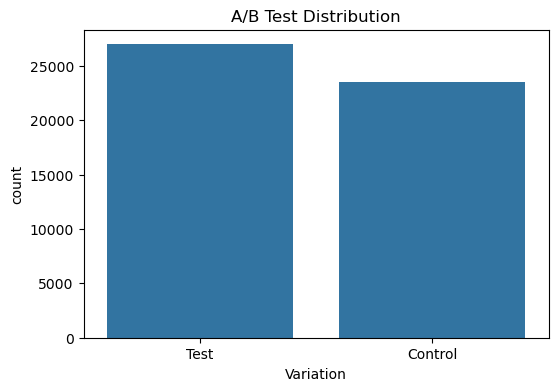

Variation
Test       0.53402
Control    0.46598
Name: proportion, dtype: float64


In [25]:
plt.figure(figsize=(6,4))
sns.countplot(x="Variation", data=df_fec)

plt.title("A/B Test Distribution")
plt.show()

print(df_fec["Variation"].value_counts(normalize=True))

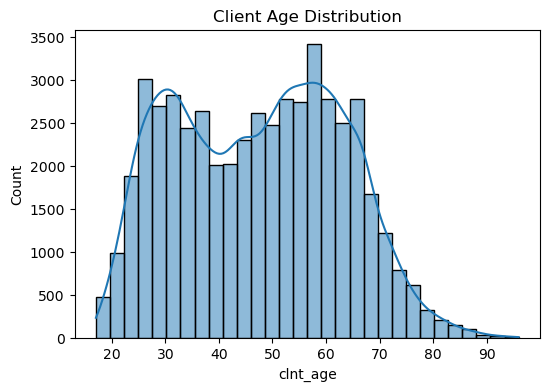

In [26]:
plt.figure(figsize=(6,4))
sns.histplot(df_fd["clnt_age"], bins=30, kde=True)

plt.title("Client Age Distribution")
plt.show()

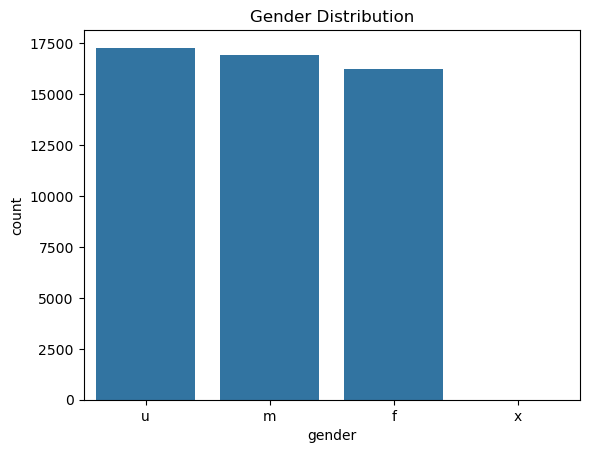

In [27]:
sns.countplot(x="gender", data=df_fd)
plt.title("Gender Distribution")
plt.show()

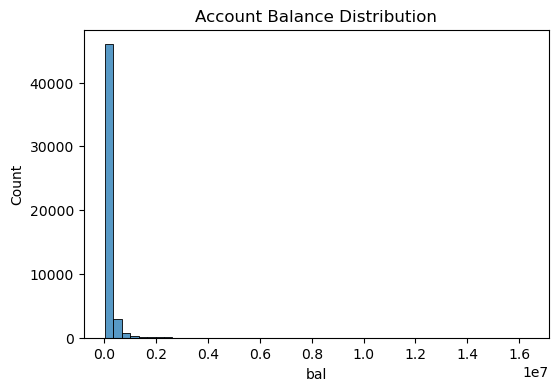

In [28]:
plt.figure(figsize=(6,4))
sns.histplot(df_fd["bal"], bins=50)

plt.title("Account Balance Distribution")
plt.show()

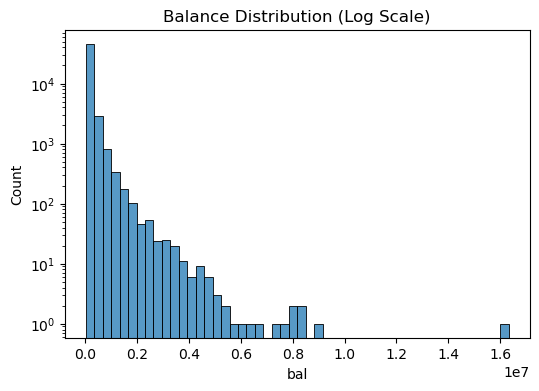

In [29]:
plt.figure(figsize=(6,4))
sns.histplot(df_fd["bal"], bins=50)
plt.yscale("log")

plt.title("Balance Distribution (Log Scale)")
plt.show()

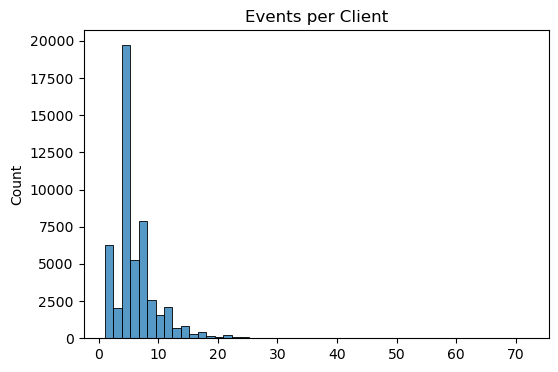

In [30]:
# Web behavior analysis

events_per_client = df_web.groupby("client_id").size()

plt.figure(figsize=(6,4))
sns.histplot(events_per_client, bins=50)

plt.title("Events per Client")
plt.show()

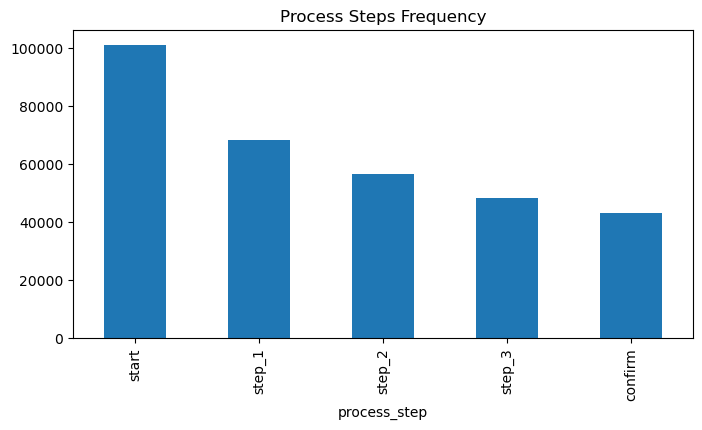

In [31]:
plt.figure(figsize=(8,4))
df_web["process_step"].value_counts().plot(kind="bar")

plt.title("Process Steps Frequency")
plt.show()


In [32]:
# Initial merge

df = df_fd.merge(df_fec, on="client_id", how="inner")

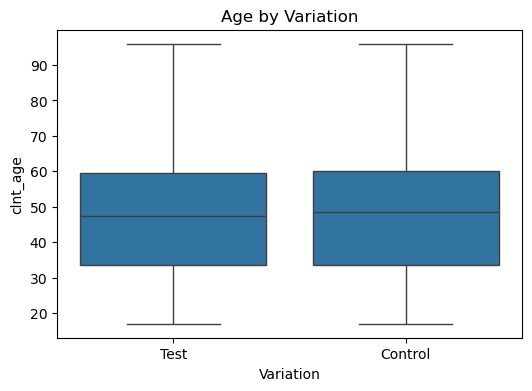

In [33]:
# Control vs Test

plt.figure(figsize=(6,4))
sns.boxplot(x="Variation", y="clnt_age", data=df)

plt.title("Age by Variation")
plt.show()

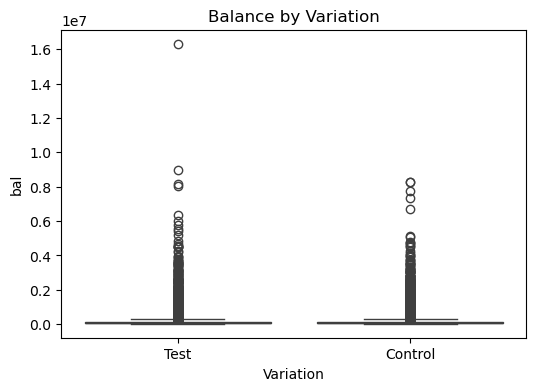

In [34]:
plt.figure(figsize=(6,4))
sns.boxplot(x="Variation", y="bal", data=df)

plt.title("Balance by Variation")
plt.show()

In [35]:
df.describe()

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,num_accts,bal,calls_6_mnth,logons_6_mnth
count,5.048800e+04,50488.000000,50488.000000,50488.000000,50488.000000,5.048800e+04,50488.000000,50488.000000
mean,5.006173e+06,12.031730,150.415485,47.319789,2.254575,1.495147e+05,3.093289,6.131873
std,2.877417e+06,6.860282,81.944830,15.518462,0.533671,3.020364e+05,2.187991,2.175423
min,5.550000e+02,2.000000,33.000000,17.000000,1.000000,2.378944e+04,0.000000,3.000000
25%,2.515700e+06,6.000000,82.000000,33.500000,2.000000,3.987841e+04,1.000000,4.000000
50%,5.025026e+06,11.000000,136.000000,48.000000,2.000000,6.573360e+04,3.000000,6.000000
75%,7.477918e+06,16.000000,192.000000,59.500000,2.000000,1.399565e+05,5.000000,8.000000
max,9.999832e+06,55.000000,669.000000,96.000000,7.000000,1.632004e+07,6.000000,9.000000


In [36]:
summary = {
    "avg_age": df["clnt_age"].mean(),
    "median_age": df["clnt_age"].median(),
    "avg_tenure_years": df["clnt_tenure_yr"].mean(),
    "avg_accounts": df["num_accts"].mean(),
    "avg_balance": df["bal"].mean(),
    "avg_logins_6m": df["logons_6_mnth"].mean()
}

print(summary)

{'avg_age': np.float64(47.31978886071938), 'median_age': 48.0, 'avg_tenure_years': np.float64(12.031730312153384), 'avg_accounts': np.float64(2.2545753446363492), 'avg_balance': np.float64(149514.6757364126), 'avg_logins_6m': np.float64(6.1318729202978925)}


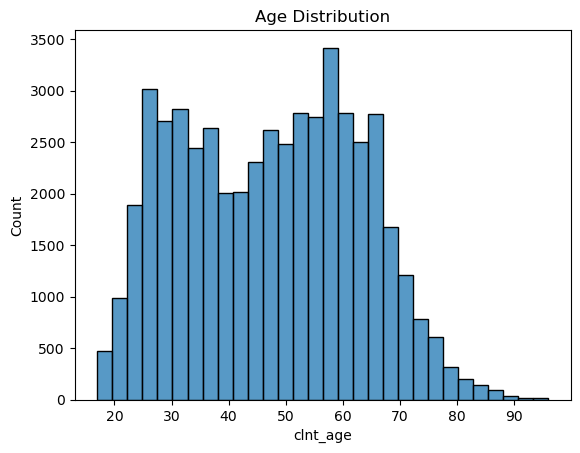

In [37]:
#Distributions
#Age

sns.histplot(df["clnt_age"], bins=30)
plt.title("Age Distribution")
plt.show()

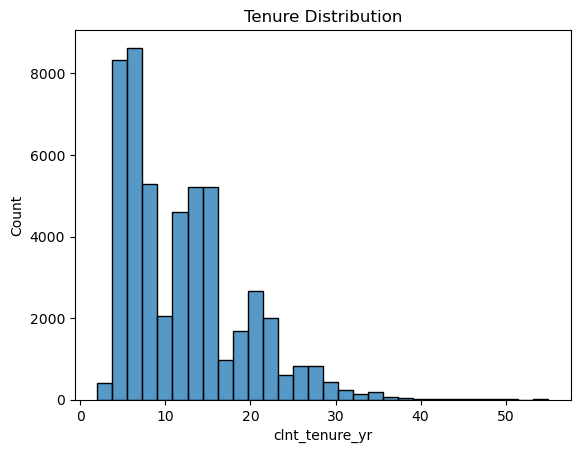

In [38]:
#Tenure

sns.histplot(df["clnt_tenure_yr"], bins=30)
plt.title("Tenure Distribution")
plt.show()

In [39]:
# Creating groups by age

df["age_group"] = pd.cut(
    df["clnt_age"],
    bins=[0, 30, 50, 70, 100],
    labels=["Young", "Mid-age", "Older", "Senior"]
)

In [40]:
# Creating group by tenure

df["tenure_group"] = pd.cut(
    df["clnt_tenure_yr"],
    bins=[0, 2, 5, 10, 50],
    labels=["New", "Recent", "Established", "Loyal"]
)

In [41]:
df["age_group"].value_counts(normalize=True)
df["tenure_group"].value_counts(normalize=True)

tenure_group
Loyal          0.510579
Established    0.316494
Recent         0.171718
New            0.001208
Name: proportion, dtype: float64

In [42]:
# Youger or older? New or long-standing?

pd.crosstab(df["age_group"], df["tenure_group"], normalize="index")

tenure_group,New,Recent,Established,Loyal
age_group,,,,
Young,0.001766,0.329765,0.424567,0.243902
Mid-age,0.001093,0.151659,0.324531,0.522716
Older,0.001202,0.133009,0.277892,0.587896
Senior,0.000316,0.079305,0.204107,0.716272


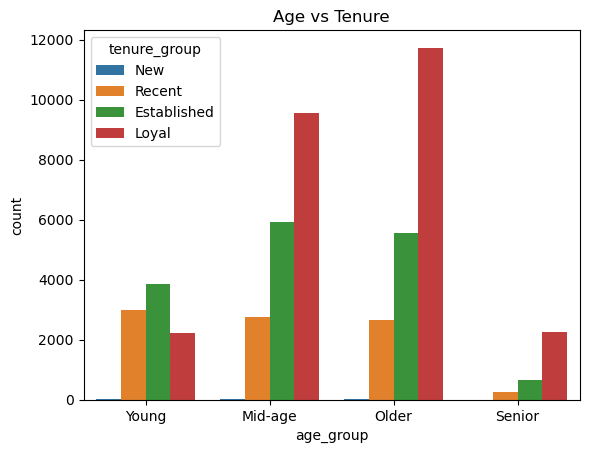

In [43]:
sns.countplot(x="age_group", hue="tenure_group", data=df)
plt.title("Age vs Tenure")
plt.show()

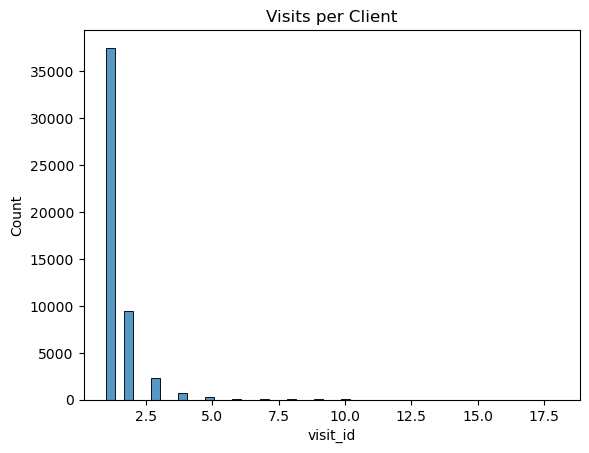

In [44]:
# Client behaviour analysis

visits = df_web.groupby("client_id")["visit_id"].nunique()

sns.histplot(visits, bins=50)
plt.title("Visits per Client")
plt.show()

In [45]:
# events per client
events = df_web.groupby("client_id").size()

In [46]:
# Engagement
df_behavior = pd.DataFrame({
    "visits": visits,
    "events": events
}).reset_index()

In [47]:
df_full = df.merge(df_behavior, on="client_id", how="left")

In [48]:
# Who are the most active?

df_full.groupby("age_group")["visits"].mean()
df_full.groupby("tenure_group")["visits"].mean()

C:\Users\Utilizador\AppData\Local\Temp\ipykernel_60916\1320255905.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_full.groupby("age_group")["visits"].mean()
C:\Users\Utilizador\AppData\Local\Temp\ipykernel_60916\1320255905.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_full.groupby("tenure_group")["visits"].mean()


tenure_group
New            1.573770
Recent         1.326373
Established    1.339822
Loyal          1.412874
Name: visits, dtype: float64

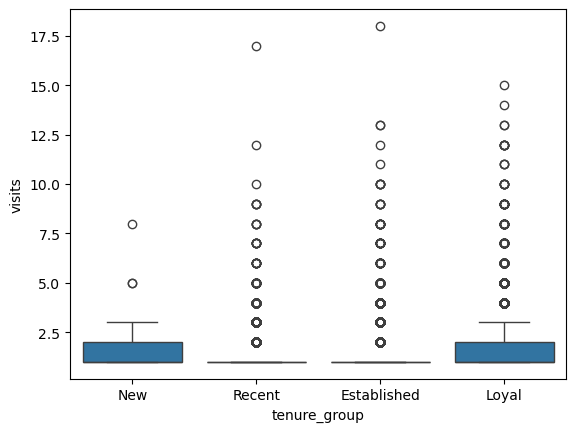

In [49]:
sns.boxplot(x="tenure_group", y="visits", data=df_full)
plt.show()

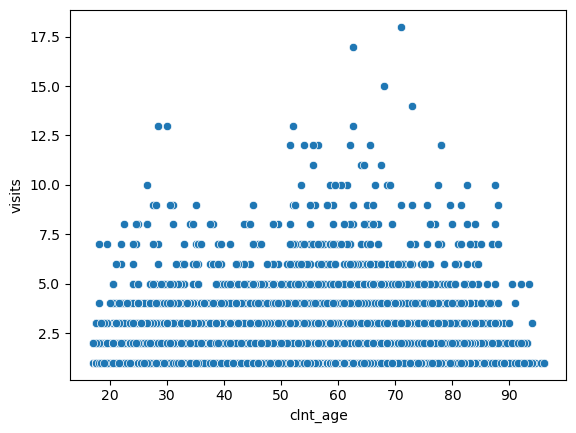

In [50]:
# Age vs engagement
sns.scatterplot(x="clnt_age", y="visits", data=df_full)
plt.show()

In [51]:
df_full.groupby("Variation")["visits"].mean()

Variation
Control    1.370213
Test       1.379400
Name: visits, dtype: float64

In [52]:
df_web = df_web.sort_values(["client_id", "visit_id", "date_time"])

In [53]:
# sessions completed
completed = df_web[df_web["process_step"] == "confirm"]["visit_id"].nunique()

# total sessions
total_visits = df_web["visit_id"].nunique()

completion_rate = completed / total_visits
print("Completion Rate:", completion_rate)

Completion Rate: 0.5444693302507044


In [74]:
# sessions completed by group
df_web_var = df_web.merge(df_fec, on="client_id", how="left")

completion_by_var = (
    df_web_var.groupby("Variation")
    .apply(lambda x: x[x["process_step"] == "confirm"]["visit_id"].nunique() / x["visit_id"].nunique())
)

print(completion_by_var)

Variation
Control    0.498493
Test       0.585173
dtype: float64


C:\Users\Utilizador\AppData\Local\Temp\ipykernel_60916\789774243.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x[x["process_step"] == "confirm"]["visit_id"].nunique() / x["visit_id"].nunique())


In [55]:
df_web["date_time"] = pd.to_datetime(df_web["date_time"], errors="coerce")

In [56]:
df_web = df_web.sort_values(["visit_id", "date_time"])

In [57]:
df_web["next_time"] = df_web.groupby("visit_id")["date_time"].shift(-1)
df_web["time_spent"] = (df_web["next_time"] - df_web["date_time"]).dt.total_seconds()

In [58]:
print(df_web["date_time"].dtype)

datetime64[ns]


In [60]:
time_per_step = df_web.groupby("process_step")["time_spent"].mean()
print(time_per_step)

process_step
confirm    227.794217
start       63.784578
step_1      56.432796
step_2      90.305110
step_3     133.097391
Name: time_spent, dtype: float64


In [61]:
df_web_var = df_web.merge(df_fec, on="client_id", how="left")

time_per_step_var = df_web_var.groupby(["Variation", "process_step"])["time_spent"].mean()
print(time_per_step_var)

Variation  process_step
Control    confirm         180.146051
           start            66.804757
           step_1           50.535583
           step_2           92.043223
           step_3          137.224496
Test       confirm         250.566239
           start            61.454595
           step_1           60.756987
           step_2           88.876116
           step_3          129.607488
Name: time_spent, dtype: float64


In [62]:
df_web["prev_step"] = df_web.groupby("visit_id")["process_step"].shift(1)

# erro se step atual < step anterior (precisas de ordem)
step_order = {
    "start": 1,
    "step_1": 2,
    "step_2": 3,
    "confirm": 4
}

df_web["step_num"] = df_web["process_step"].map(step_order)
df_web["prev_step_num"] = df_web["prev_step"].map(step_order)

df_web["is_error"] = df_web["step_num"] < df_web["prev_step_num"]

In [63]:
error_rate = df_web["is_error"].mean()
print("Error rate:", error_rate)

Error rate: 0.05335476854697622


In [64]:
df_web_var = df_web.merge(df_fec, on="client_id", how="left")

error_by_var = df_web_var.groupby("Variation")["is_error"].mean()
print(error_by_var)

Variation
Control    0.038083
Test       0.065501
Name: is_error, dtype: float64


In [66]:
# Drop-off rate per step
step_counts = df_web["process_step"].value_counts()
drop_off = step_counts.pct_change()

In [67]:
#Average steps per session
steps_per_visit = df_web.groupby("visit_id").size().mean()

In [68]:
#Conversion funnel
df_web["process_step"].value_counts(normalize=True)

process_step
start      0.318858
step_1     0.215014
step_2     0.178644
step_3     0.152140
confirm    0.135344
Name: proportion, dtype: float64

In [75]:
# Abandonment Rate

completed_visits = df_web[df_web["process_step"] == "confirm"]["visit_id"].unique()

df_web["is_abandoned"] = ~df_web["visit_id"].isin(completed_visits)

In [76]:
abandonment_rate = df_web["is_abandoned"].mean()

In [77]:
abandonment_rate

np.float64(0.3384935457941274)

In [78]:
total_visits = df_web["visit_id"].nunique()
completed = len(completed_visits)

abandonment_rate = 1 - (completed / total_visits)

In [79]:
abandonment_rate

0.45553066974929557

In [ ]:
######


In [80]:
# sorting
df_web = df_web.sort_values(["visit_id", "date_time"])

# last event for each step
last_step = df_web.groupby("visit_id").tail(1)

# distribution
last_step_counts = last_step["process_step"].value_counts(normalize=True)
print(last_step_counts)

process_step
confirm    0.530467
start      0.275789
step_1     0.095788
step_3     0.057785
step_2     0.040171
Name: proportion, dtype: float64


In [ ]:
# conversion rate between steps

# drop-off at each stage

# comparison between Control vs Test

In [81]:
# Merge variation into web data
df_web_var = df_web.merge(df_fec, on="client_id", how="left")

# Ensure correct ordering of events
df_web_var["date_time"] = pd.to_datetime(df_web_var["date_time"], errors="coerce")
df_web_var = df_web_var.dropna(subset=["date_time"])

df_web_var = df_web_var.sort_values(["visit_id", "date_time"])

In [82]:
# Define the correct funnel order
steps = ["start", "step_1", "step_2", "step_3", "confirm"]

In [83]:
# Create a pivot table: rows = visit_id, columns = steps, values = presence (1/0)
funnel = (
    df_web_var
    .assign(value=1)
    .pivot_table(index=["visit_id", "Variation"],
                 columns="process_step",
                 values="value",
                 aggfunc="max",
                 fill_value=0)
)

# Ensure all steps exist (in case some are missing)
for step in steps:
    if step not in funnel.columns:
        funnel[step] = 0

# Reorder columns
funnel = funnel[steps]

funnel.head()

,process_step,start,step_1,step_2,step_3,confirm
visit_id,Variation,,,,,
100012776_37918976071_457913,Test,0,0,0,0,1
100019538_17884295066_43909,Test,1,1,1,1,1
100022086_87870757897_149620,Test,1,1,1,1,1
100030127_47967100085_936361,Control,1,0,0,0,0
100037962_47432393712_705583,Control,1,1,0,0,0


In [84]:
# Count how many visits reached each step per Variation
funnel_counts = funnel.groupby("Variation")[steps].sum()

print(funnel_counts)

process_step  start  step_1  step_2  step_3  confirm
Variation                                           
Control       30910   23548   20138   18300    16046
Test          33157   28285   24503   22186    21731


In [85]:
# Calculate conversion rates step-by-step
funnel_conversion = funnel_counts.copy()

for i in range(1, len(steps)):
    funnel_conversion[steps[i]] = (
        funnel_counts[steps[i]] / funnel_counts[steps[i-1]]
    )

# First step is always 1 (baseline)
funnel_conversion["start"] = 1.0

print(funnel_conversion)

process_step  start    step_1    step_2   step_3   confirm
Variation                                                 
Control         1.0  0.761825  0.855189  0.90873  0.876831
Test            1.0  0.853063  0.866290  0.90544  0.979492


In [86]:
# Drop-off = 1 - conversion
funnel_dropoff = 1 - funnel_conversion

print(funnel_dropoff)

process_step  start    step_1    step_2   step_3   confirm
Variation                                                 
Control         0.0  0.238175  0.144811  0.09127  0.123169
Test            0.0  0.146937  0.133710  0.09456  0.020508


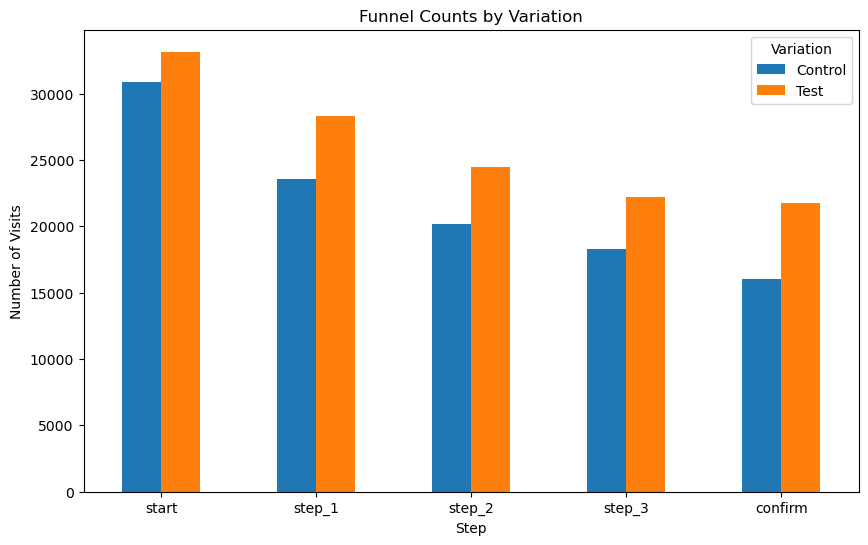

In [87]:
import matplotlib.pyplot as plt

funnel_counts.T.plot(kind="bar", figsize=(10,6))

plt.title("Funnel Counts by Variation")
plt.xlabel("Step")
plt.ylabel("Number of Visits")
plt.xticks(rotation=0)

plt.show()

In [88]:
funnel_diff = funnel_conversion.loc["Test"] - funnel_conversion.loc["Control"]
print(funnel_diff)

process_step
start      0.000000
step_1     0.091238
step_2     0.011100
step_3    -0.003290
confirm    0.102661
dtype: float64


In [89]:
# total de sessões
total_visits = df_web["visit_id"].nunique()

# sessões que têm pelo menos um start
visits_with_start = df_web[df_web["process_step"] == "start"]["visit_id"].nunique()

# sessões sem start
visits_without_start = total_visits - visits_with_start

print("Total visits:", total_visits)
print("Visits with start:", visits_with_start)
print("Visits without start:", visits_without_start)
print("Share without start:", visits_without_start / total_visits)

Total visits: 69205
Visits with start: 63951
Visits without start: 5254
Share without start: 0.07591936998771764


In [90]:
# garantir ordem temporal
df_web["date_time"] = pd.to_datetime(df_web["date_time"], errors="coerce")
df_web = df_web.dropna(subset=["date_time"])
df_web = df_web.sort_values(["visit_id", "date_time"])

# primeiro evento de cada sessão
first_step = df_web.groupby("visit_id").first().reset_index()

# distribuição do primeiro passo
print(first_step["process_step"].value_counts())
print(first_step["process_step"].value_counts(normalize=True))

process_step
start      63730
confirm     4146
step_1       603
step_3       441
step_2       285
Name: count, dtype: int64
process_step
start      0.920887
confirm    0.059909
step_1     0.008713
step_3     0.006372
step_2     0.004118
Name: proportion, dtype: float64


In [91]:
non_start_sessions = first_step[first_step["process_step"] != "start"]

print("Sessions not starting at 'start':", non_start_sessions["visit_id"].nunique())
print(non_start_sessions["process_step"].value_counts())

Sessions not starting at 'start': 5475
process_step
confirm    4146
step_1      603
step_3      441
step_2      285
Name: count, dtype: int64


In [92]:
example_visits = non_start_sessions["visit_id"].head(10).tolist()

df_web[df_web["visit_id"].isin(example_visits)].sort_values(["visit_id", "date_time"])

,client_id,visitor_id,visit_id,process_step,date_time,next_time,time_spent,prev_step,step_num,prev_step_num,is_error,is_abandoned
111665,3561384,451664975_1722933822,100012776_37918976071_457913,confirm,2017-04-26 13:22:17,2017-04-26 13:23:09,52.0,NaN,4.0,NaN,False,False
111666,3561384,451664975_1722933822,100012776_37918976071_457913,confirm,2017-04-26 13:23:09,NaT,NaN,confirm,4.0,4.0,False,False
106449,3393250,796176251_17286375741,100475449_39139591577_836652,confirm,2017-04-04 09:21:46,NaT,NaN,NaN,4.0,NaN,False,False
137808,4389198,729937373_63248482072,100618014_41463020246_787063,confirm,2017-05-11 09:13:00,2017-05-11 09:13:46,46.0,NaN,4.0,NaN,False,False
137809,4389198,729937373_63248482072,100618014_41463020246_787063,start,2017-05-11 09:13:46,2017-05-11 09:21:51,485.0,confirm,1.0,4.0,True,False
137810,4389198,729937373_63248482072,100618014_41463020246_787063,step_1,2017-05-11 09:21:51,NaT,NaN,start,2.0,1.0,False,False
313787,9886162,771235499_63497281090,100762504_13289430422_745035,confirm,2017-03-29 21:06:16,NaT,NaN,NaN,4.0,NaN,False,False
29696,942896,468136757_13704551082,100995466_7789612733_596938,confirm,2017-03-30 08:36:52,NaT,NaN,NaN,4.0,NaN,False,False
5861,174238,658583569_78036299439,101140215_44015987399_153386,confirm,2017-04-16 22:39:20,NaT,NaN,NaN,4.0,NaN,False,False
203816,6446363,739479428_1803291083,101389230_14746485715_507991,confirm,2017-05-22 08:31:58,NaT,NaN,NaN,4.0,NaN,False,False


In [93]:
df_web_var = df_web.merge(df_fec, on="client_id", how="left")

first_step_var = (
    df_web_var
    .sort_values(["visit_id", "date_time"])
    .groupby("visit_id")
    .first()
    .reset_index()
)

not_start_by_var = (
    first_step_var.assign(not_start=first_step_var["process_step"] != "start")
    .groupby("Variation")["not_start"]
    .mean()
)

print(not_start_by_var)

Variation
Control    0.041594
Test       0.111608
Name: not_start, dtype: float64


In [94]:
first_step = df_web.sort_values(["visit_id", "date_time"]).groupby("visit_id").first().reset_index()
first_step["process_step"].value_counts(normalize=True)

process_step
start      0.920887
confirm    0.059909
step_1     0.008713
step_3     0.006372
step_2     0.004118
Name: proportion, dtype: float64

In [95]:
########

# Sorting by client
df_web = df_web.sort_values(["client_id", "date_time"])

In [96]:
#Identifying first step of each session

first_step = (
    df_web.groupby("visit_id")
    .first()
    .reset_index()[["visit_id", "client_id", "process_step", "date_time"]]
)

first_step = first_step.rename(columns={"process_step": "first_step"})

In [97]:
# start events
df_web["is_start"] = df_web["process_step"] == "start"

# cumulative per client
df_web["had_start_before"] = df_web.groupby("client_id")["is_start"].cumsum().shift(1).fillna(0) > 0

In [98]:
# info by session
first_event_flags = (
    df_web.groupby("visit_id")
    .first()
    .reset_index()[["visit_id", "client_id", "had_start_before"]]
)

# join with first_step
session_info = first_step.merge(first_event_flags, on=["visit_id", "client_id"])

In [99]:
#classifying sessions
def classify(row):
    if row["first_step"] == "start":
        return "fresh_start"
    elif row["had_start_before"]:
        return "resumed"
    else:
        return "orphan"

session_info["session_type"] = session_info.apply(classify, axis=1)

print(session_info["session_type"].value_counts(normalize=True))

session_type
fresh_start    0.920887
resumed        0.074778
orphan         0.004335
Name: proportion, dtype: float64


In [100]:
# Examination by variation

session_info_var = session_info.merge(df_fec, on="client_id", how="left")

print(
    session_info_var.groupby("Variation")["session_type"]
    .value_counts(normalize=True)
)

Variation  session_type
Control    fresh_start     0.958447
           resumed         0.040868
           orphan          0.000685
Test       fresh_start     0.888340
           resumed         0.104162
           orphan          0.007498
Name: proportion, dtype: float64


In [101]:
# The redesigned experience significantly increases the proportion of resumed sessions, indicating that users are more likely to return and continue the process rather than completing it in a single session.

In [ ]:
# The redesign shifts user behavior from a single-session completion model to a multi-session journey, where users pause and resume the process before completing it.

In [102]:
# Merge session classification into web data
df_web_full = df_web.merge(session_info[["visit_id", "session_type"]], on="visit_id", how="left")

# Merge variation
df_web_full = df_web_full.merge(df_fec, on="client_id", how="left")

# Keep only valid sessions (exclude orphan if desired)
df_web_full = df_web_full[df_web_full["session_type"] != "orphan"]

In [103]:
# Create combined grouping variable
def group_label(row):
    if row["Variation"] == "Control":
        return "Control"
    elif row["Variation"] == "Test" and row["session_type"] == "fresh_start":
        return "Test_fresh"
    elif row["Variation"] == "Test" and row["session_type"] == "resumed":
        return "Test_resumed"

df_web_full["group"] = df_web_full.apply(group_label, axis=1)

In [104]:
# Identify completed visits
completed_visits = df_web_full[df_web_full["process_step"] == "confirm"]["visit_id"].unique()

completion = {}

for g in df_web_full["group"].dropna().unique():
    df_g = df_web_full[df_web_full["group"] == g]
    
    total = df_g["visit_id"].nunique()
    completed = df_g[df_g["visit_id"].isin(completed_visits)]["visit_id"].nunique()
    
    completion[g] = completed / total

print("Completion Rate by group:")
print(completion)

Completion Rate by group:
{'Test_fresh': 0.5407789058948326, 'Control': 0.4985233313644418, 'Test_resumed': 0.9360600569505566}


In [105]:
# Ensure ordering
df_web_full = df_web_full.sort_values(["visit_id", "date_time"])

# Compute time to next step
df_web_full["next_time"] = df_web_full.groupby("visit_id")["date_time"].shift(-1)
df_web_full["time_spent"] = (df_web_full["next_time"] - df_web_full["date_time"]).dt.total_seconds()

# Average time per step and group
time_per_step = df_web_full.groupby(["group", "process_step"])["time_spent"].mean()

print("\nTime spent per step:")
print(time_per_step)


Time spent per step:
group         process_step
Control       confirm         180.023964
              start            66.804757
              step_1           50.514071
              step_2           91.987908
              step_3          137.237055
Test_fresh    confirm         264.863682
              start            61.395229
              step_1           60.592755
              step_2           88.916888
              step_3          129.652985
Test_resumed  confirm         211.669716
              start            79.121951
              step_1           66.842536
              step_2           87.017742
              step_3          128.611348
Name: time_spent, dtype: float64


In [106]:
# Error Rate
# Define step order
step_order = {
    "start": 1,
    "step_1": 2,
    "step_2": 3,
    "step_3": 4,
    "confirm": 5
}

# Previous step
df_web_full["prev_step"] = df_web_full.groupby("visit_id")["process_step"].shift(1)

# Map to numeric
df_web_full["step_num"] = df_web_full["process_step"].map(step_order)
df_web_full["prev_step_num"] = df_web_full["prev_step"].map(step_order)

# Error = moving backwards
df_web_full["is_error"] = df_web_full["step_num"] < df_web_full["prev_step_num"]

# Compute error rate
error_rate = df_web_full.groupby("group")["is_error"].mean()

print("\nError rate by group:")
print(error_rate)


Error rate by group:
group
Control         0.069028
Test_fresh      0.094106
Test_resumed    0.056821
Name: is_error, dtype: float64


In [109]:
# 1 Strict funnel 
# Only includes sessions whose first observed step is start
# Filter valid sessions

In [110]:
# Ensure proper time ordering
df_web_full = df_web_full.sort_values(["visit_id", "date_time"])

# Identify first step per session
first_step = (
    df_web_full.groupby("visit_id")
    .first()
    .reset_index()[["visit_id", "process_step"]]
)

# Keep only sessions starting at 'start'
valid_start_visits = first_step[first_step["process_step"] == "start"]["visit_id"]

df_strict = df_web_full[df_web_full["visit_id"].isin(valid_start_visits)]

In [111]:
# Completion Rate
# Identify completed sessions
completed_visits = df_strict[df_strict["process_step"] == "confirm"]["visit_id"].unique()

# Total sessions per variation
total_sessions = df_strict.groupby("Variation")["visit_id"].nunique()

# Completed sessions per variation
completed_sessions = (
    df_strict[df_strict["visit_id"].isin(completed_visits)]
    .groupby("Variation")["visit_id"].nunique()
)

completion_strict = completed_sessions / total_sessions

print("Strict completion rate:")
print(completion_strict)

Strict completion rate:
Variation
Control    0.482335
Test       0.540765
Name: visit_id, dtype: float64


In [112]:
# Funnel 

steps = ["start", "step_1", "step_2", "step_3", "confirm"]

# Build session-level funnel
funnel_strict = (
    df_strict.assign(value=1)
    .pivot_table(index=["visit_id", "Variation"],
                 columns="process_step",
                 values="value",
                 aggfunc="max",
                 fill_value=0)
)

# Count sessions reaching each step
funnel_counts_strict = funnel_strict.groupby("Variation")[steps].sum()

# Compute conversion rates
funnel_conversion_strict = funnel_counts_strict.copy()

for i in range(1, len(steps)):
    funnel_conversion_strict[steps[i]] = (
        funnel_counts_strict[steps[i]] / funnel_counts_strict[steps[i-1]]
    )

funnel_conversion_strict["start"] = 1.0

print("\nStrict funnel conversion:")
print(funnel_conversion_strict)


Strict funnel conversion:
process_step  start    step_1    step_2    step_3   confirm
Variation                                                  
Control         1.0  0.752950  0.849806  0.901423  0.835628
Test            1.0  0.845664  0.860686  0.896019  0.828972


In [ ]:
# This represents a true start-to-end funnel, where all sessions follow the same entry point. It isolates the pure UX impact of the redesign, removing bias from resumed or fragmented sessions.

In [113]:
# 2 Behavioral Journey
# fresh start + resumed


In [114]:
df_behavioral = df_web_full[df_web_full["session_type"] != "orphan"]

In [115]:
completion_behavioral = {}

for g in df_behavioral["group"].dropna().unique():
    df_g = df_behavioral[df_behavioral["group"] == g]
    
    total = df_g["visit_id"].nunique()
    completed = df_g[df_g["process_step"] == "confirm"]["visit_id"].nunique()
    
    completion_behavioral[g] = completed / total

print("Behavioral completion rate:")
print(completion_behavioral)

Behavioral completion rate:
{'Test_resumed': 0.9360600569505566, 'Test_fresh': 0.5406273677829975, 'Control': 0.49818136599620727}


In [116]:
df_behavioral = df_behavioral.sort_values(["visit_id", "date_time"])

df_behavioral["next_time"] = df_behavioral.groupby("visit_id")["date_time"].shift(-1)
df_behavioral["time_spent"] = (
    df_behavioral["next_time"] - df_behavioral["date_time"]
).dt.total_seconds()

time_per_step = df_behavioral.groupby(["group", "process_step"])["time_spent"].mean()

print("\nTime spent per step:")
print(time_per_step)


Time spent per step:
group         process_step
Control       confirm         180.023964
              start            66.804757
              step_1           50.514071
              step_2           91.987908
              step_3          137.237055
Test_fresh    confirm         264.863682
              start            61.395229
              step_1           60.592755
              step_2           88.916888
              step_3          129.652985
Test_resumed  confirm         211.669716
              start            79.121951
              step_1           66.842536
              step_2           87.017742
              step_3          128.611348
Name: time_spent, dtype: float64


In [117]:
# Error rate

step_order = {
    "start": 1,
    "step_1": 2,
    "step_2": 3,
    "step_3": 4,
    "confirm": 5
}

df_behavioral["prev_step"] = df_behavioral.groupby("visit_id")["process_step"].shift(1)

df_behavioral["step_num"] = df_behavioral["process_step"].map(step_order)
df_behavioral["prev_step_num"] = df_behavioral["prev_step"].map(step_order)

df_behavioral["is_error"] = df_behavioral["step_num"] < df_behavioral["prev_step_num"]

error_rate = df_behavioral.groupby("group")["is_error"].mean()

print("\nError rate:")
print(error_rate)


Error rate:
group
Control         0.069028
Test_fresh      0.094106
Test_resumed    0.056821
Name: is_error, dtype: float64


In [ ]:
# This analysis reflects real user behavior, including multi-session journeys and cross-device continuation. It captures both UX effects and behavioral changes introduced by the redesign.

In [118]:
# ordenar corretamente
df_web_full = df_web_full.sort_values(["client_id", "date_time"])

# último step de cada sessão
last_step = (
    df_web_full.groupby("visit_id")
    .last()
    .reset_index()[["visit_id", "client_id", "process_step", "date_time", "group"]]
)

last_step = last_step.rename(columns={"process_step": "last_step"})

In [119]:
# próxima sessão do mesmo cliente
last_step["next_session_time"] = (
    last_step.groupby("client_id")["date_time"].shift(-1)
)

# sessão interrompida = não terminou + tem continuação
last_step["interrupted"] = (
    (last_step["last_step"] != "confirm") &
    (last_step["next_session_time"].notna())
)

In [120]:
interrupt_distribution = (
    last_step[last_step["interrupted"]]
    .groupby(["group", "last_step"])
    .size()
    .groupby(level=0)
    .apply(lambda x: x / x.sum())
)

print(interrupt_distribution)

group         group         last_step
Control       Control       start        0.585309
                            step_1       0.224009
                            step_2       0.077765
                            step_3       0.112917
Test_fresh    Test_fresh    start        0.588938
                            step_1       0.214878
                            step_2       0.095009
                            step_3       0.101176
Test_resumed  Test_resumed  start        0.340580
                            step_1       0.173913
                            step_2       0.159420
                            step_3       0.326087
dtype: float64


In [121]:
last_step["time_to_resume"] = (
    last_step["next_session_time"] - last_step["date_time"]
).dt.total_seconds() / 60  # minutos

print(
    last_step[last_step["interrupted"]]
    .groupby("group")["time_to_resume"]
    .describe()
)

               count         mean           std            min          25%  \
group                                                                         
Control       6031.0  7482.382408  35489.131051 -128028.716667 -5680.100000   
Test_fresh    5189.0  7667.877841  36748.273276 -116452.600000 -3252.816667   
Test_resumed   138.0  1135.093478  14116.271911  -69011.350000   -10.266667   

                      50%           75%            max  
group                                                   
Control        748.116667  20167.825000  139564.916667  
Test_fresh    2084.316667  21716.066667  119694.833333  
Test_resumed    -2.933333     45.170833   60812.083333  
